长度分布如下：
长度 2: 1 条
长度 3: 2 条
长度 4: 22 条
长度 5: 56 条
长度 6: 101 条
长度 7: 126 条
长度 8: 129 条
长度 9: 319 条
长度 10: 1535 条
长度 11: 7368 条
长度 12: 15660 条
长度 13: 20660 条
长度 14: 25318 条
长度 15: 25970 条
长度 16: 11512 条
长度 17: 8042 条
长度 18: 2402 条
长度 19: 1099 条
长度 20: 571 条
长度 21: 183 条
长度 22: 78 条
长度 23: 82 条
长度 24: 24 条
长度 25: 41 条
长度 26: 524 条
长度 27: 6 条

未指定长度，自动选择最常见长度: 15
最终用于绘图的序列数: 25970

前几行频率矩阵：
          A         C         D         E         F         G         H  \
1  0.000000  1.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2  0.922796  0.000000  0.000039  0.000655  0.000077  0.003928  0.000000   
3  0.071737  0.000308  0.000886  0.015287  0.007278  0.020870  0.000308   
4  0.018367  0.000462  0.039507  0.021178  0.001733  0.032191  0.002195   
5  0.058953  0.000385  0.071929  0.058914  0.029842  0.063535  0.013939   

          I         K         L         M         N         P         Q  \
1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2  0.0077

<Figure size 1000x400 with 0 Axes>

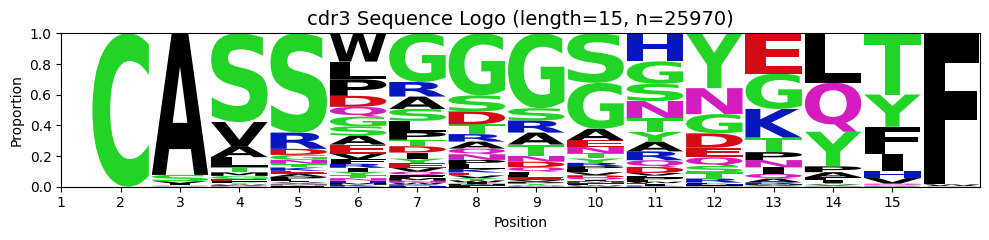

图已保存到: cdr3_logo.png


In [2]:
import os
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import logomaker


AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")


def read_table(file_path: str) -> pd.DataFrame:
    """
    根据文件扩展名自动读取表格文件。
    支持: csv, tsv, txt, xlsx, xls
    """
    file_path = str(file_path)
    suffix = Path(file_path).suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(file_path)
    elif suffix in [".tsv", ".txt"]:
        return pd.read_csv(file_path, sep="\t")
    elif suffix in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)
    else:
        raise ValueError(f"不支持的文件类型: {suffix}")


def clean_cdr3_series(df: pd.DataFrame, column_name: str = "CDR3(pep)") -> pd.Series:
    """
    清洗 CDR3 序列列：
    - 去空值
    - 转大写
    - 去除前后空格
    - 只保留标准20种氨基酸字符组成的序列
    """
    if column_name not in df.columns:
        raise KeyError(f"文件中找不到列: {column_name}")

    seqs = (
        df[column_name]
        .dropna()
        .astype(str)
        .str.strip()
        .str.upper()
    )

    valid_set = set(AMINO_ACIDS)

    def is_valid_seq(seq: str) -> bool:
        return len(seq) > 0 and all(ch in valid_set for ch in seq)

    seqs = seqs[seqs.map(is_valid_seq)]

    if len(seqs) == 0:
        raise ValueError("清洗后没有可用的 CDR3 序列，请检查列内容是否为标准氨基酸序列。")

    return seqs


def select_sequences_by_length(seqs: pd.Series, target_length: int = None) -> pd.Series:
    """
    选择指定长度的序列。
    如果 target_length=None，则自动选出现次数最多的长度。
    """
    lengths = seqs.str.len()
    length_counts = lengths.value_counts().sort_index()

    print("长度分布如下：")
    for length, count in length_counts.items():
        print(f"长度 {length}: {count} 条")

    if target_length is None:
        target_length = lengths.mode().iloc[0]
        print(f"\n未指定长度，自动选择最常见长度: {target_length}")
    else:
        print(f"\n指定使用长度: {target_length}")

    selected = seqs[lengths == target_length]

    if len(selected) == 0:
        raise ValueError(f"没有长度为 {target_length} 的序列。")

    print(f"最终用于绘图的序列数: {len(selected)}")
    return selected


def build_frequency_matrix(seqs: pd.Series) -> pd.DataFrame:
    """
    将等长氨基酸序列构造成 position × amino acid 的频率矩阵
    """
    seq_list = seqs.tolist()
    seq_len = len(seq_list[0])

    # 确保等长
    if any(len(seq) != seq_len for seq in seq_list):
        raise ValueError("输入序列不是等长，无法直接绘制 sequence logo。")

    matrix = []
    n = len(seq_list)

    for i in range(seq_len):
        column_residues = [seq[i] for seq in seq_list]
        counts = Counter(column_residues)

        row = {aa: counts.get(aa, 0) / n for aa in AMINO_ACIDS}
        matrix.append(row)

    freq_df = pd.DataFrame(matrix)
    freq_df.index = range(1, seq_len + 1)  # 位置从1开始

    return freq_df


def plot_sequence_logo(
    freq_df: pd.DataFrame,
    title: str = "CDR3 Sequence Logo",
    output_png: str = "cdr3_logo.png",
    figsize=(10, 4),
    dpi: int = 300
) -> None:
    """
    绘制 sequence logo 并保存
    """
    plt.figure(figsize=figsize)
    logo = logomaker.Logo(freq_df)

    plt.title(title, fontsize=14)
    plt.xlabel("Position")
    plt.ylabel("Proportion")
    plt.xticks(range(len(freq_df)), freq_df.index)
    plt.tight_layout()
    plt.savefig(output_png, dpi=dpi, bbox_inches="tight")
    plt.show()

    print(f"图已保存到: {output_png}")


def main(
    file_path: str,
    column_name: str = "CDR3(pep)",
    target_length: int = None,
    output_png: str = "cdr3_logo.png"
) -> None:
    """
    主流程：
    1. 读取文件
    2. 提取并清洗 CDR3(pep)
    3. 选择某一长度的序列
    4. 生成频率矩阵
    5. 绘制 sequence logo
    """
    df = read_table(file_path)
    seqs = clean_cdr3_series(df, column_name=column_name)
    selected_seqs = select_sequences_by_length(seqs, target_length=target_length)
    freq_df = build_frequency_matrix(selected_seqs)

    print("\n前几行频率矩阵：")
    print(freq_df.head())

    plot_sequence_logo(
        freq_df=freq_df,
        title=f"{column_name} Sequence Logo (length={len(selected_seqs.iloc[0])}, n={len(selected_seqs)})",
        output_png=output_png
    )


if __name__ == "__main__":
    # ===== 改这里 =====
    file_path = "/workspace/zhengqinyun/project/TCRFunction/TESSA-1.3.0/data/CD8/Donor1/vdj_v1_hs_aggregated_donor1_all_contig_annotations.csv"       # 你的文件路径
    column_name = "cdr3"         # 你的列名
    target_length = None              # None=自动选最常见长度；比如改成 5 / 6 / 12 也行
    output_png = "cdr3_logo.png"      # 输出图片名
    # ==================

    main(
        file_path=file_path,
        column_name=column_name,
        target_length=target_length,
        output_png=output_png
    )